# Applied ML for Security Detection
### Starter Notebook 2 of 4 — AI-Assisted ML for Cybersecurity

**Audience:** Students who completed `01_ml_foundations.ipynb`.

**Goal:** Train baseline detectors and learn the **evaluation metrics that matter in a SOC** — confusion matrix, precision, recall, F1, ROC-AUC — and why **accuracy alone is misleading** for rare attacks. Then tune the decision **threshold** for the false-positive / false-negative trade-off you actually want.

> **Reproducibility:** runs fully offline on `scikit-learn` + `matplotlib`. The dataset is synthesized in-notebook (same generator as notebook 1).

## 🛠️ Setup — rebuild the dataset & split

In [1]:
# If needed:  !pip install -q numpy pandas scikit-learn matplotlib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def make_security_events(n=2000, frac_malicious=0.2, seed=42):
    """Same synthetic 'connection events' dataset as notebook 1 (1=malicious)."""
    rng = np.random.default_rng(seed)
    n_mal = int(n * frac_malicious); n_ben = n - n_mal

    def block(size, fl, bs, br, dur, hr, ports):
        return pd.DataFrame({
            "failed_logins": rng.poisson(fl, size),
            "bytes_sent":    rng.normal(*bs, size).clip(0),
            "bytes_recv":    rng.normal(*br, size).clip(0),
            "duration_s":    rng.normal(*dur, size).clip(0),
            "unusual_hour":  rng.binomial(1, hr, size),
            "ports_touched": rng.poisson(ports, size),
        })

    benign = block(n_ben, 0.5, (2000, 600), (5000, 1500), (30, 10), 0.05, 1.5); benign["label"] = 0
    malicious = block(n_mal, 4.0, (8000, 3000), (3000, 1500), (80, 40), 0.5, 8.0); malicious["label"] = 1
    df = pd.concat([benign, malicious], ignore_index=True)
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


df = make_security_events()
features = ["failed_logins", "bytes_sent", "bytes_recv", "duration_s", "unusual_hour", "ports_touched"]
X, y = df[features], df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)          # fit on train only (no leakage)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print("Ready. Train:", X_train_s.shape, " Test:", X_test_s.shape,
      " Test malicious rate:", round(y_test.mean(), 3))

Ready. Train: (1500, 6)  Test: (500, 6)  Test malicious rate: 0.2


# 🎯 1 — A Baseline Classifier

- Start simple: logistic regression
- A baseline sets the bar fancier models must beat
- Fit on train, predict on the held-out test set
- `predict` → labels; `predict_proba` → scores
- Never report training accuracy as success

> ### 🎤 Instructor Script
>
> Always start with a simple, fast baseline; it tells you whether the problem is learnable and gives later models something to beat. We fit a logistic-regression classifier on the scaled training data and predict on the untouched test set. Two outputs matter: `predict` gives a hard benign/malicious label using the default 0.5 cutoff, while `predict_proba` gives the underlying probability score we will later threshold ourselves. Resist the urge to quote training accuracy — a model can memorize training data; the only number that counts is performance on data it has never seen.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)                       # hard labels at the 0.5 cutoff
y_score = clf.predict_proba(X_test_s)[:, 1]          # P(malicious) for each event

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("First 5 predicted probabilities:", np.round(y_score[:5], 3))

Test accuracy: 1.0
First 5 predicted probabilities: [0.006 0.    0.    1.    0.001]


# 🪤 2 — Why Accuracy Lies

- Attacks are rare → classes are imbalanced
- A 'predict benign always' model scores high accuracy
- …and catches **zero** attacks
- Accuracy hides failure on the class you care about
- Need metrics that focus on the positive (attack) class

> ### 🎤 Instructor Script
>
> Here is the trap that fools beginners. Because attacks are rare, a lazy model that labels everything benign can score, say, eighty percent accuracy — while catching not a single attack. We build exactly that dummy model and compare its accuracy to our classifier's. The accuracies look close, but they are worlds apart in usefulness. The dummy is worthless for security. This is why, for rare-event detection, we abandon accuracy as our headline metric and turn to precision, recall, and the confusion matrix, which describe performance on the attack class specifically.

In [3]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train_s, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test_s))

print(f"'Always benign' accuracy : {dummy_acc:.3f}  (catches 0 attacks!)")
print(f"Logistic regression acc  : {accuracy_score(y_test, y_pred):.3f}")
print("\nSimilar accuracy, totally different value -> accuracy is the wrong headline metric.")

'Always benign' accuracy : 0.800  (catches 0 attacks!)
Logistic regression acc  : 1.000

Similar accuracy, totally different value -> accuracy is the wrong headline metric.


# 🔢 3 — The Confusion Matrix

- Four outcomes: TP, FP, FN, TN
- **FN** = missed attack (dangerous)
- **FP** = false alarm (analyst fatigue)
- Everything else is derived from these counts
- Read it before trusting any single score

> ### 🎤 Instructor Script
>
> The confusion matrix is the source of truth from which every other metric is derived. It cross-tabs predictions against reality into four cells: true positives (attacks caught), true negatives (benign correctly cleared), false positives (false alarms), and false negatives (missed attacks). In security these two errors are not equal: a false negative is a breach you never saw, while a false positive is an analyst's wasted time. Looking at the raw counts keeps you honest — a single summary number can hide a pile of missed attacks, but the confusion matrix shows them directly.

True Negatives :  400   False Positives:    0  (false alarms)
False Negatives:    0   True Positives :  100  (attacks caught)

Missed attacks (FN): 0   |  False alarms (FP): 0


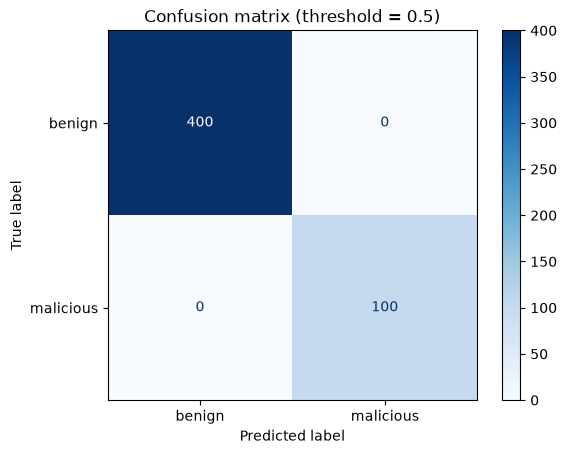

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn:4d}   False Positives: {fp:4d}  (false alarms)")
print(f"False Negatives: {fn:4d}   True Positives : {tp:4d}  (attacks caught)")
print(f"\nMissed attacks (FN): {fn}   |  False alarms (FP): {fp}")

ConfusionMatrixDisplay(cm, display_labels=["benign", "malicious"]).plot(cmap="Blues")
plt.title("Confusion matrix (threshold = 0.5)"); plt.show()

# 📐 4 — Precision, Recall, F1

- **Precision** = of alerts raised, how many were real?
- **Recall** = of real attacks, how many did we catch?
- Trade-off: chase recall and precision usually drops
- **F1** balances the two in one number
- Pick the metric that matches your operational cost

> ### 🎤 Instructor Script
>
> Precision and recall answer the two questions a SOC actually cares about. Precision asks: when we raise an alert, how often is it a real attack? Low precision means alert fatigue. Recall asks: of all the real attacks, how many did we catch? Low recall means breaches slip through. They trade off — push the model to catch more attacks and it raises more false alarms. F1 is their harmonic mean, a single balanced score. The classification report gives all three per class. Which one you optimize is a business decision: a bank may demand high recall on fraud and tolerate false alarms; a noisy IDS may need precision to stay usable.

In [5]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_pred), 3),
      " Recall:", round(recall_score(y_test, y_pred), 3),
      " F1:", round(f1_score(y_test, y_pred), 3), "\n")
print(classification_report(y_test, y_pred, target_names=["benign", "malicious"]))

Precision: 1.0  Recall: 1.0  F1: 1.0 

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00       400
   malicious       1.00      1.00      1.00       100

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



# 📈 5 — ROC-AUC: Ranking Quality

- ROC sweeps every possible threshold
- Plots true-positive vs false-positive rate
- **AUC** = probability a random attack outranks a random benign
- 0.5 = coin flip, 1.0 = perfect ranking
- Threshold-independent measure of the score's quality

> ### 🎤 Instructor Script
>
> Precision and recall depend on a chosen cutoff, but how good is the model's underlying score, independent of any threshold? That is what ROC-AUC measures. The ROC curve sweeps the threshold from strict to lenient and traces the true-positive rate against the false-positive rate. The area under that curve, the AUC, has a clean interpretation: the probability that the model gives a random real attack a higher score than a random benign event. Half is a coin flip; one is perfect ranking. AUC is great for comparing models, but remember it summarizes all thresholds at once — you still have to pick one to actually operate, which is the next topic.

ROC-AUC: 1.0  (0.5 = random, 1.0 = perfect)


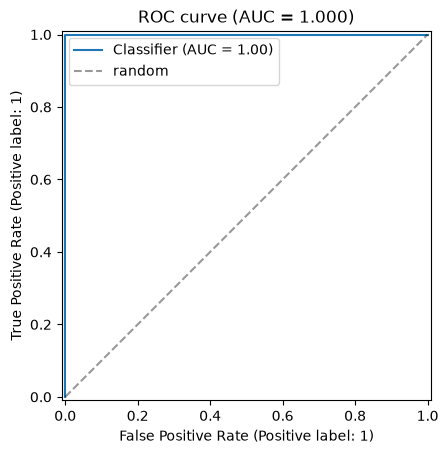

In [6]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

auc = roc_auc_score(y_test, y_score)
print("ROC-AUC:", round(auc, 3), " (0.5 = random, 1.0 = perfect)")

RocCurveDisplay.from_predictions(y_test, y_score)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
plt.title(f"ROC curve (AUC = {auc:.3f})"); plt.legend(); plt.show()

# 🎛️ 6 — Tuning the Threshold (FP vs FN)

- 0.5 is a default, not a law
- Lower threshold → catch more attacks, more false alarms
- Raise threshold → fewer alarms, more misses
- Choose based on the **cost** of each error
- Report the threshold you actually deploy

> ### 🎤 Instructor Script
>
> The default 0.5 cutoff is arbitrary; the right threshold depends on what each mistake costs you. We assign a cost to a missed attack and a smaller cost to a false alarm, then sweep every threshold and pick the one that minimizes total cost. Watch how the optimal point moves: when missed attacks are expensive, the model should fire more readily, accepting extra false alarms to drive down false negatives. This is the heart of applied detection — you are not just training a model, you are tuning an operating point to match real-world consequences, and you should always report the threshold you actually deploy.

In [7]:
COST_FN = 20.0   # cost of a missed attack (breach)
COST_FP = 1.0    # cost of a false alarm (analyst time)

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    pred = (y_score >= t).astype(int)
    cm = confusion_matrix(y_test, pred); tn, fp, fn, tp = cm.ravel()
    rows.append((t, fp, fn, COST_FN * fn + COST_FP * fp))

table = pd.DataFrame(rows, columns=["threshold", "false_alarms", "missed_attacks", "total_cost"])
best = table.loc[table["total_cost"].idxmin()]
print(table.to_string(index=False))
print(f"\nBest threshold = {best.threshold:.2f}  "
      f"(missed={int(best.missed_attacks)}, false_alarms={int(best.false_alarms)}, "
      f"cost={best.total_cost:.0f})")
print("Compare with default 0.5 -> tuning the threshold is a security decision, not a default.")

 threshold  false_alarms  missed_attacks  total_cost
      0.05             3               0         3.0
      0.10             1               0         1.0
      0.15             1               0         1.0
      0.20             1               0         1.0
      0.25             0               0         0.0
      0.30             0               0         0.0
      0.35             0               0         0.0
      0.40             0               0         0.0
      0.45             0               0         0.0
      0.50             0               0         0.0
      0.55             0               0         0.0
      0.60             0               0         0.0
      0.65             0               0         0.0
      0.70             0               0         0.0
      0.75             0               0         0.0
      0.80             0               0         0.0
      0.85             0               1        20.0
      0.90             0               3      

# ✅ Summary — Applied Detection

- Baseline first; beat it deliberately
- Accuracy lies under class imbalance
- Read the confusion matrix (FN vs FP)
- Precision/recall/F1 describe the attack class
- ROC-AUC rates the score; threshold sets the operating point
- Next → ensembles, imbalance handling, clustering & anomalies

> ### 🎤 Instructor Script
>
> We trained a baseline detector and, more importantly, learned to judge it like a security practitioner. Accuracy collapses under imbalance, so we read the confusion matrix directly and reported precision, recall, and F1 for the attack class. ROC-AUC told us how well the model ranks attacks above benign events independent of any cutoff, and then we chose a threshold by minimizing the real cost of misses versus false alarms. In the next notebook we push accuracy and robustness further with ensembles, proper imbalance handling, and unsupervised methods for discovering attacks we have no labels for.

In [8]:
print("Applied detection complete.")
print("Headline metrics for the attack class:")
print("  precision:", round(precision_score(y_test, y_pred), 3),
      " recall:", round(recall_score(y_test, y_pred), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, y_score), 3))
print("\nNext: 03_advanced_ml_analytics.ipynb -> ensembles, imbalance, clustering, anomalies.")

Applied detection complete.
Headline metrics for the attack class:
  precision: 1.0  recall: 1.0  ROC-AUC: 1.0

Next: 03_advanced_ml_analytics.ipynb -> ensembles, imbalance, clustering, anomalies.
